Episode 001/1000 | StartTime 2026-03-19 17:06:54 | MaxQChange 13.371414 | QueueLength 6940 | Reward    -30748.00 | Epsilon 0.997 | EpStates  223 | NewStates  223 | TotalStates   223
Episode 002/1000 | StartTime 2026-03-19 17:06:59 | MaxQChange 14.547479 | QueueLength 8252 | Reward    -40799.00 | Epsilon 0.993 | EpStates  198 | NewStates   85 | TotalStates   308
Episode 003/1000 | StartTime 2026-03-19 17:07:03 | MaxQChange 13.709040 | QueueLength 7746 | Reward    -36741.00 | Epsilon 0.990 | EpStates  217 | NewStates   64 | TotalStates   372
Episode 004/1000 | StartTime 2026-03-19 17:07:07 | MaxQChange 14.909956 | QueueLength 7472 | Reward    -34032.00 | Epsilon 0.987 | EpStates  230 | NewStates   62 | TotalStates   434
Episode 005/1000 | StartTime 2026-03-19 17:07:12 | MaxQChange 16.634609 | QueueLength 7997 | Reward    -38882.00 | Epsilon 0.983 | EpStates  234 | NewStates   48 | TotalStates   482
Episode 006/1000 | StartTime 2026-03-19 17:07:16 | MaxQChange 16.487598 | QueueLength 7742

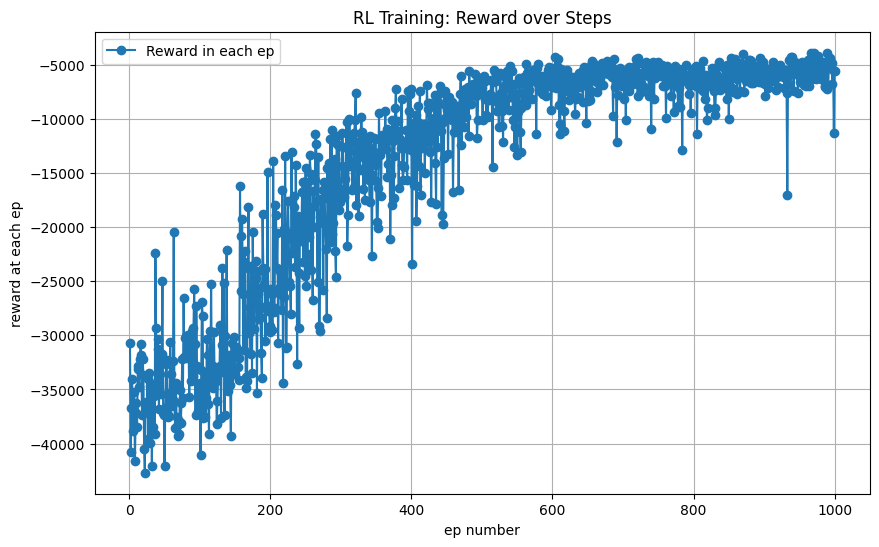

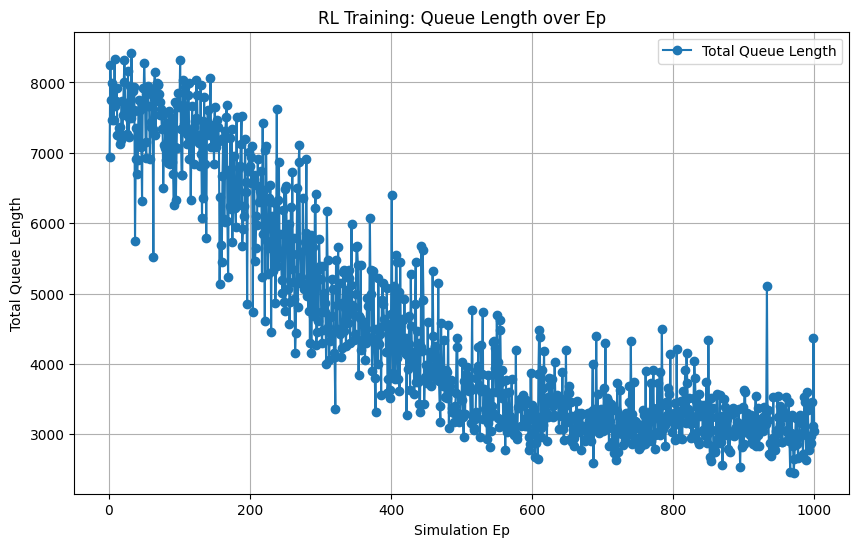

In [ ]:
from QL import QLearningAgent

import traci 
import pickle 
import numpy as np 
import matplotlib.pyplot as plt
import random
from collections import defaultdict
from datetime import datetime
import pytz

sumo_exe = r"C:\Program Files (x86)\Eclipse\Sumo\bin\sumo.exe"
sumo_cfg = r"C:\Users\OMEN\Desktop\jun1\jun1.sumocfg"

episode = 1000
max_step = 1000
alpha = 0.05
gamma = 0.92

max_green = 30
min_green = 5
max_red = 3

n=900
e = 1
e_min = 0.05
e_decay = (0.05)**(1/n)
green_ph = [0,2,4,6]
red_ph = [1,3,5,7]
total_ph = 8
last_switch_step = 0

state_size = 5
action_size = 4

agent = QLearningAgent(state_size=state_size,action_size=action_size,alpha=alpha,gamma=gamma,epsilon=e,epsilon_decay=e_decay,epsilon_min=e_min)

tls_id = "cluster_26785788_26785789_26785790_26785791_4286289674_4286289675_4286289676_4286289679"

APPROACH_A = ['429488376#0_0', '429488376#0_1', '429488376#0_2', '429488376#0_3']
APPROACH_B = ['429488375#0_0', '429488375#0_1', '429488375#0_2']
APPROACH_C = ['328440060#1_0', '328440060#1_1', '328440060#1_2', '328440060#1_3']
APPROACH_D = ['338690994#0_0', '338690994#0_1', '338690994#0_2' , '338690994#0_3']

def queueOfSubLane(subLaneNo):
    return (traci.lane.getLastStepHaltingNumber(subLaneNo))
    
def maxQueueLength(laneList):
    a=[]
    for lane in laneList:
       a.append(queueOfSubLane(lane))
    return max(a)

def get_state(tls_id):
    A = maxQueueLength(APPROACH_A)
    B = maxQueueLength(APPROACH_B)
    C = maxQueueLength(APPROACH_C)
    D = maxQueueLength(APPROACH_D)
    L = traci.trafficlight.getPhase(tls_id)
    return (A, B, C, D, L)

def get_reward(state):
    A, B, C, D, _ = state
    return -(A*A + B*B + C*C + D*D)


def NextPhase(action,phase):
    if action == 1:
        return (phase + 2) % total_ph
    elif action == 2:
        return (phase + 4) % total_ph
    elif action == 3:
        return (phase + 6) % total_ph
    return phase
    
def YPhase(phase):
    return (phase + 1) % total_ph

    
def is_G(phase):
    return phase in green_ph

def current_phase(tls_id): 
    return traci.trafficlight.getPhase(tls_id)

def mustSwitch(phase,duration):
    if (phase in green_ph and duration >= max_green):
        return True
    elif (phase in red_ph and duration >= max_red):
        return True
    return False
    
def canRLAct(phase,duration):
    if (phase in green_ph and (duration >= min_green) and (duration < max_green )):
        return True
    return False

queue_history =[]
ep_history = []
reward_history = []
all_states = set()

for ep in range(1, episode + 1):
    ep_start_time = datetime.now(pytz.timezone("Asia/Kolkata")).strftime("%Y-%m-%d %H:%M:%S")
    ep_history.append(ep)

    traci.start([sumo_exe,"-c", sumo_cfg,"--no-step-log","--quit-on-end"])
    total_ph = len(traci.trafficlight.getAllProgramLogics(tls_id)[0].phases)
    phase_prev = traci.trafficlight.getPhase(tls_id)

    ep_reward = 0
    ep_states = set()    
    new_states = set()  
    total_ep_queue = 0
    
    max_q_change = 0
    step =0
    done = False
    while step < max_step:
        switch = False
        if(step == max_step-1):
            done = True

        discounted_reward = 0
        old_state = get_state(tls_id)
        action = agent.choose_action(old_state)
        phase = current_phase(tls_id)
        duration = traci.trafficlight.getSpentDuration(tls_id)
        total_ep_queue+= sum(old_state[:4])

        if(mustSwitch(phase,duration)):
            if phase in green_ph:
                if(action == 0 ):
                    action =  random.randint(1, 3)
                traci.trafficlight.setPhase(tls_id, (phase+1)%total_ph)
                traci.trafficlight.setPhaseDuration(tls_id, 3)
                for i in range(0,3):
                    traci.simulationStep()
                    switch = True
                    di_state = get_state(tls_id)
                    ep_reward+= get_reward(di_state)
                    total_ep_queue+= sum(di_state[:4])
                    discounted_reward+= get_reward(di_state) * (gamma ** i)
                step = step + 3 
                nextPhase = NextPhase(action,phase)
                traci.trafficlight.setPhase(tls_id,nextPhase)
                traci.trafficlight.setPhaseDuration(tls_id, 31)

            elif phase in red_ph:
                action = 1
                traci.trafficlight.setPhase(tls_id, (phase+1)%total_ph)
            
            phase = current_phase(tls_id)
            duration = traci.trafficlight.getSpentDuration(tls_id)

            if(phase in green_ph):
                traci.trafficlight.setPhaseDuration(tls_id, 31)
            else:
                traci.trafficlight.setPhaseDuration(tls_id, 3)

        elif(canRLAct(phase,duration)):
            if(action == 0):
                traci.trafficlight.setPhase(tls_id, phase)
                traci.trafficlight.setPhaseDuration(tls_id, 31)
            else:
                traci.trafficlight.setPhase(tls_id, (phase+1)%total_ph)
                traci.trafficlight.setPhaseDuration(tls_id, 3)
                for i in range(0,3):
                    switch = True
                    traci.simulationStep()
                    di_state = get_state(tls_id)
                    ep_reward+= get_reward(di_state)
                    total_ep_queue+= sum(di_state[:4])
                    discounted_reward+= get_reward(di_state) * (gamma ** i)
                step = step + 3 
                nextPhase = NextPhase(action,phase)
                traci.trafficlight.setPhase(tls_id,nextPhase)
                traci.trafficlight.setPhaseDuration(tls_id, 31)

        traci.simulationStep()
        step += 1

        phase_curr = traci.trafficlight.getPhase(tls_id)
        new_state = get_state(tls_id)
        reward = get_reward(new_state)
        ep_reward+=reward
         
        if(switch == False): 
           delta= agent.update( state=old_state, action=action, reward=reward, next_state=new_state, done=done, power=1)
        else:
            discounted_reward += reward * (gamma ** 3)
            delta = agent.update( state=old_state, action=action, reward=discounted_reward, next_state=new_state, done=done, power=4)

        if delta > max_q_change:
            max_q_change = delta

        ep_states.add(old_state)
        if old_state not in all_states:
            new_states.add(old_state)
            all_states.add(old_state)
        
    traci.close()
    agent.decay_epsilon()
    reward_history.append(ep_reward)
    queue_history.append(total_ep_queue)
    if ep % 10 == 0:
        with open("rl_model_2.pkl", "wb") as f:
            pickle.dump(agent.q_table, f) 
            
    print( f"Episode {ep:03d}/{episode} | "f"StartTime {ep_start_time} | "f"MaxQChange {max_q_change:.6f} | "f"QueueLength {total_ep_queue} | "f"Reward {ep_reward:12.2f} | "f"Epsilon {agent.epsilon:.3f} | "f"EpStates {len(ep_states):4d} | "f"NewStates {len(new_states):4d} | "f"TotalStates {len(all_states):5d}")
     
print("\nTraining finished")
print(f"Total learned states: {len(all_states)}")        
plt.figure(figsize=(10, 6))
plt.plot(ep_history, reward_history, marker='o', linestyle='-', label="Reward in each ep")
plt.xlabel("ep number")
plt.ylabel("reward at each ep")
plt.title("RL Training: Reward over Steps")
plt.legend()
plt.grid(True) 
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(ep_history, queue_history, marker='o', linestyle='-', label="Total Queue Length")
plt.xlabel("Simulation Ep")
plt.ylabel("Total Queue Length")
plt.title("RL Training: Queue Length over Ep")
plt.legend()
plt.grid(True)
plt.show()